### Project Topic Overview

#### 1. **Explanation of the Project and Problem Type**
   - **Type of Learning:** The project involves **supervised learning**, with a focus on **neural networks for regression tasks**.
   
   - **Type of Task:** The primary task is a **regression** task, aimed at predicting a continuous target variable—specifically, the quality of wine.

   - **Problem Description:** This project explores the application of neural networks in regression, a topic mentioned in the lectures but not deeply studied in prior coursework. Previous exercises in the course covered NLP, CNNs, and GANs, but the use of neural networks for regression remained largely unexplored.
   
   - **Methods/Approach:** The project compares the performance of neural networks against traditional supervised learning models, such as Random Forests, to evaluate their effectiveness in regression tasks. The process includes data preprocessing, exploratory data analysis, model training, hyperparameter tuning, and evaluation.

#### 2. **Goal of the Project**
   - **Importance of the Project:** Understanding how well neural networks perform in regression tasks can provide valuable insights into their versatility and potential advantages over traditional models. This knowledge is crucial for applications across various domains where accurate predictions of continuous variables are essential.
   
   - **Specific Goals/Objectives:** The primary objective is to evaluate the performance of neural networks in regression tasks compared to traditional supervised learning models like Random Forests. The project aims to determine the accuracy and effectiveness of neural networks in predicting wine quality, thereby gauging their potential for broader applications in regression problems.


### Data

#### 1. **Data Description**
   - **Dataset Size:** The dataset consists of **1,599 samples (rows)** and **12 features (columns)**.
   - **Data Type:** The dataset is composed of numerical features, primarily representing various chemical properties of wine.
   - **Features Description:**
     - **Key Features:**
       - **fixed acidity:** Tartaric acid content in g/dm³.
       - **volatile acidity:** Acetic acid content in g/dm³.
       - **citric acid:** Citric acid content in g/dm³.
       - **residual sugar:** Remaining sugar after fermentation in g/dm³.
       - **chlorides:** Salt content in g/dm³.
       - **free sulfur dioxide:** Free SO2 content in mg/dm³.
       - **total sulfur dioxide:** Total SO2 content in mg/dm³.
       - **density:** Density of the wine in g/cm³.
       - **pH:** pH level.
       - **sulphates:** Potassium sulphate content in g/dm³.
       - **alcohol:** Alcohol content in % by volume.
       - **quality:** A score between 0 and 10 indicating wine quality (target variable).
   - **Data Characteristics:** The data is in a single-table format and does not involve multi-table or multi-source data.

#### 2. **Data Source**
   - The dataset is sourced from the **UCI Machine Learning Repository**, specifically from the [Wine Quality Data Set](https://archive.ics.uci.edu/ml/datasets/Wine+Quality). This dataset provides a comprehensive collection of red and white wine samples from Portugal, with the quality rating based on sensory data. The specific file used in this project is `winequality-red.csv`, which contains data on red wine samples.


### Data Cleaning

#### 1. **Data Cleaning, and scaling Steps and Justifications**

**Missing Data Check:**
- The first step in data cleaning involved checking for missing values in the dataset. The code used `data.isnull().sum()` to verify the presence of NaN values across all features.
- **Justification:** Ensuring data integrity is crucial, as missing values can impact the model's performance and the accuracy of predictions. For this dataset, there were no missing values, confirming its completeness.

**Feature Scaling:**
- **What:** The scaling of features was applied to the training, validation, and test sets using `StandardScaler`. The scaler was fitted on the training set to learn the scaling parameters (mean and standard deviation) and subsequently used to transform the validation and test sets.
- **Why:** Feature scaling was performed to normalize the range of the features, bringing them to a common scale. This is particularly important in neural networks and other machine learning algorithms to ensure consistent weight updates during training. Scaling prevents features with larger ranges from disproportionately influencing the model and helps in faster convergence during the training process. By standardizing the features, each feature contributes equally to the model's learning process, leading to potentially better model performance and stability.


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers.legacy import Adam, RMSprop, SGD
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, delimiter=';')

# Check for missing values
print(data.isnull().sum())
# No missing values in this dataset

# Display basic statistics
print(data.describe())

# Separate features and target
X = data.drop('quality', axis=1)
y = data['quality']

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dio

### Exploratory Data Analysis (EDA)

#### 1. **Purpose of EDA and Methodology**

**Purpose:**
- The primary goal of EDA is to understand the distribution and relationships of features within the dataset. This includes identifying patterns, correlations, and potential issues such as class imbalances or outliers.

**Methodology:**
- **Visualizations and Analysis Techniques:**
  - **Correlation Matrix:** Used to visualize the relationships between features, indicating how one feature may change with another.
  - **Pair Plots:** Provide a detailed view of the relationships between pairs of features, including distributions and potential correlations.
  - **Count Plot of Quality:** Illustrates the distribution of the target variable 'quality' across different levels.

#### 2. **Visualizations and Findings**

**Correlation Matrix:**
- The correlation matrix revealed several key relationships:
  - Positive correlations between 'alcohol' and 'quality', indicating that higher alcohol content may be associated with higher quality.
  - Negative correlation between 'volatile acidity' and 'quality', suggesting that higher acidity might lead to lower quality.
  - Strong positive correlation between 'density' and 'residual sugar', likely due to the increased sugar content affecting the density of the wine.

**Pair Plots:**
- Pair plots allowed for the visualization of relationships between different features, such as:
  - The spread and clustering of data points, indicating potential trends or patterns.
  - Identification of outliers in features like 'residual sugar' and 'chlorides', which may require further attention.

**Count Plot of Quality:**
- The distribution of the 'quality' variable showed a skew towards certain ratings, with fewer samples at the extremes. This indicates a potential class imbalance, which could impact the model's learning process.

#### 3. **Conclusions and Discussions**

**Summary:**
- The EDA provided valuable insights into the dataset's characteristics. Key observations include the relationships between features and the distribution of the target variable.

**Findings:**
- The analysis highlighted correlations that could influence the predictive modeling phase. For example, 'alcohol' content shows a noticeable correlation with 'quality', which could be a significant predictor.
- The presence of class imbalance in the 'quality' distribution suggests the need for potential resampling techniques or adjustment in model evaluation metrics.

**Foreseen Difficulties and Analysis Strategy:**
- Challenges identified include addressing class imbalance and managing outliers. The correlation matrix also indicated some multicollinearity, which might require further feature selection or engineering.

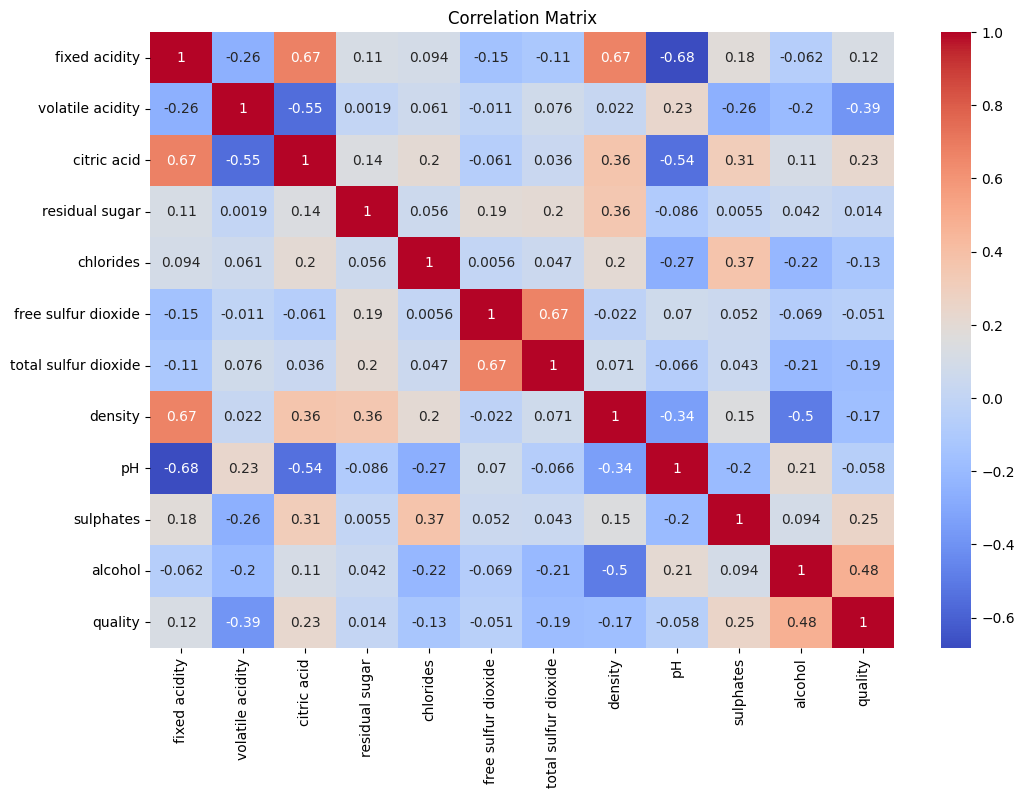

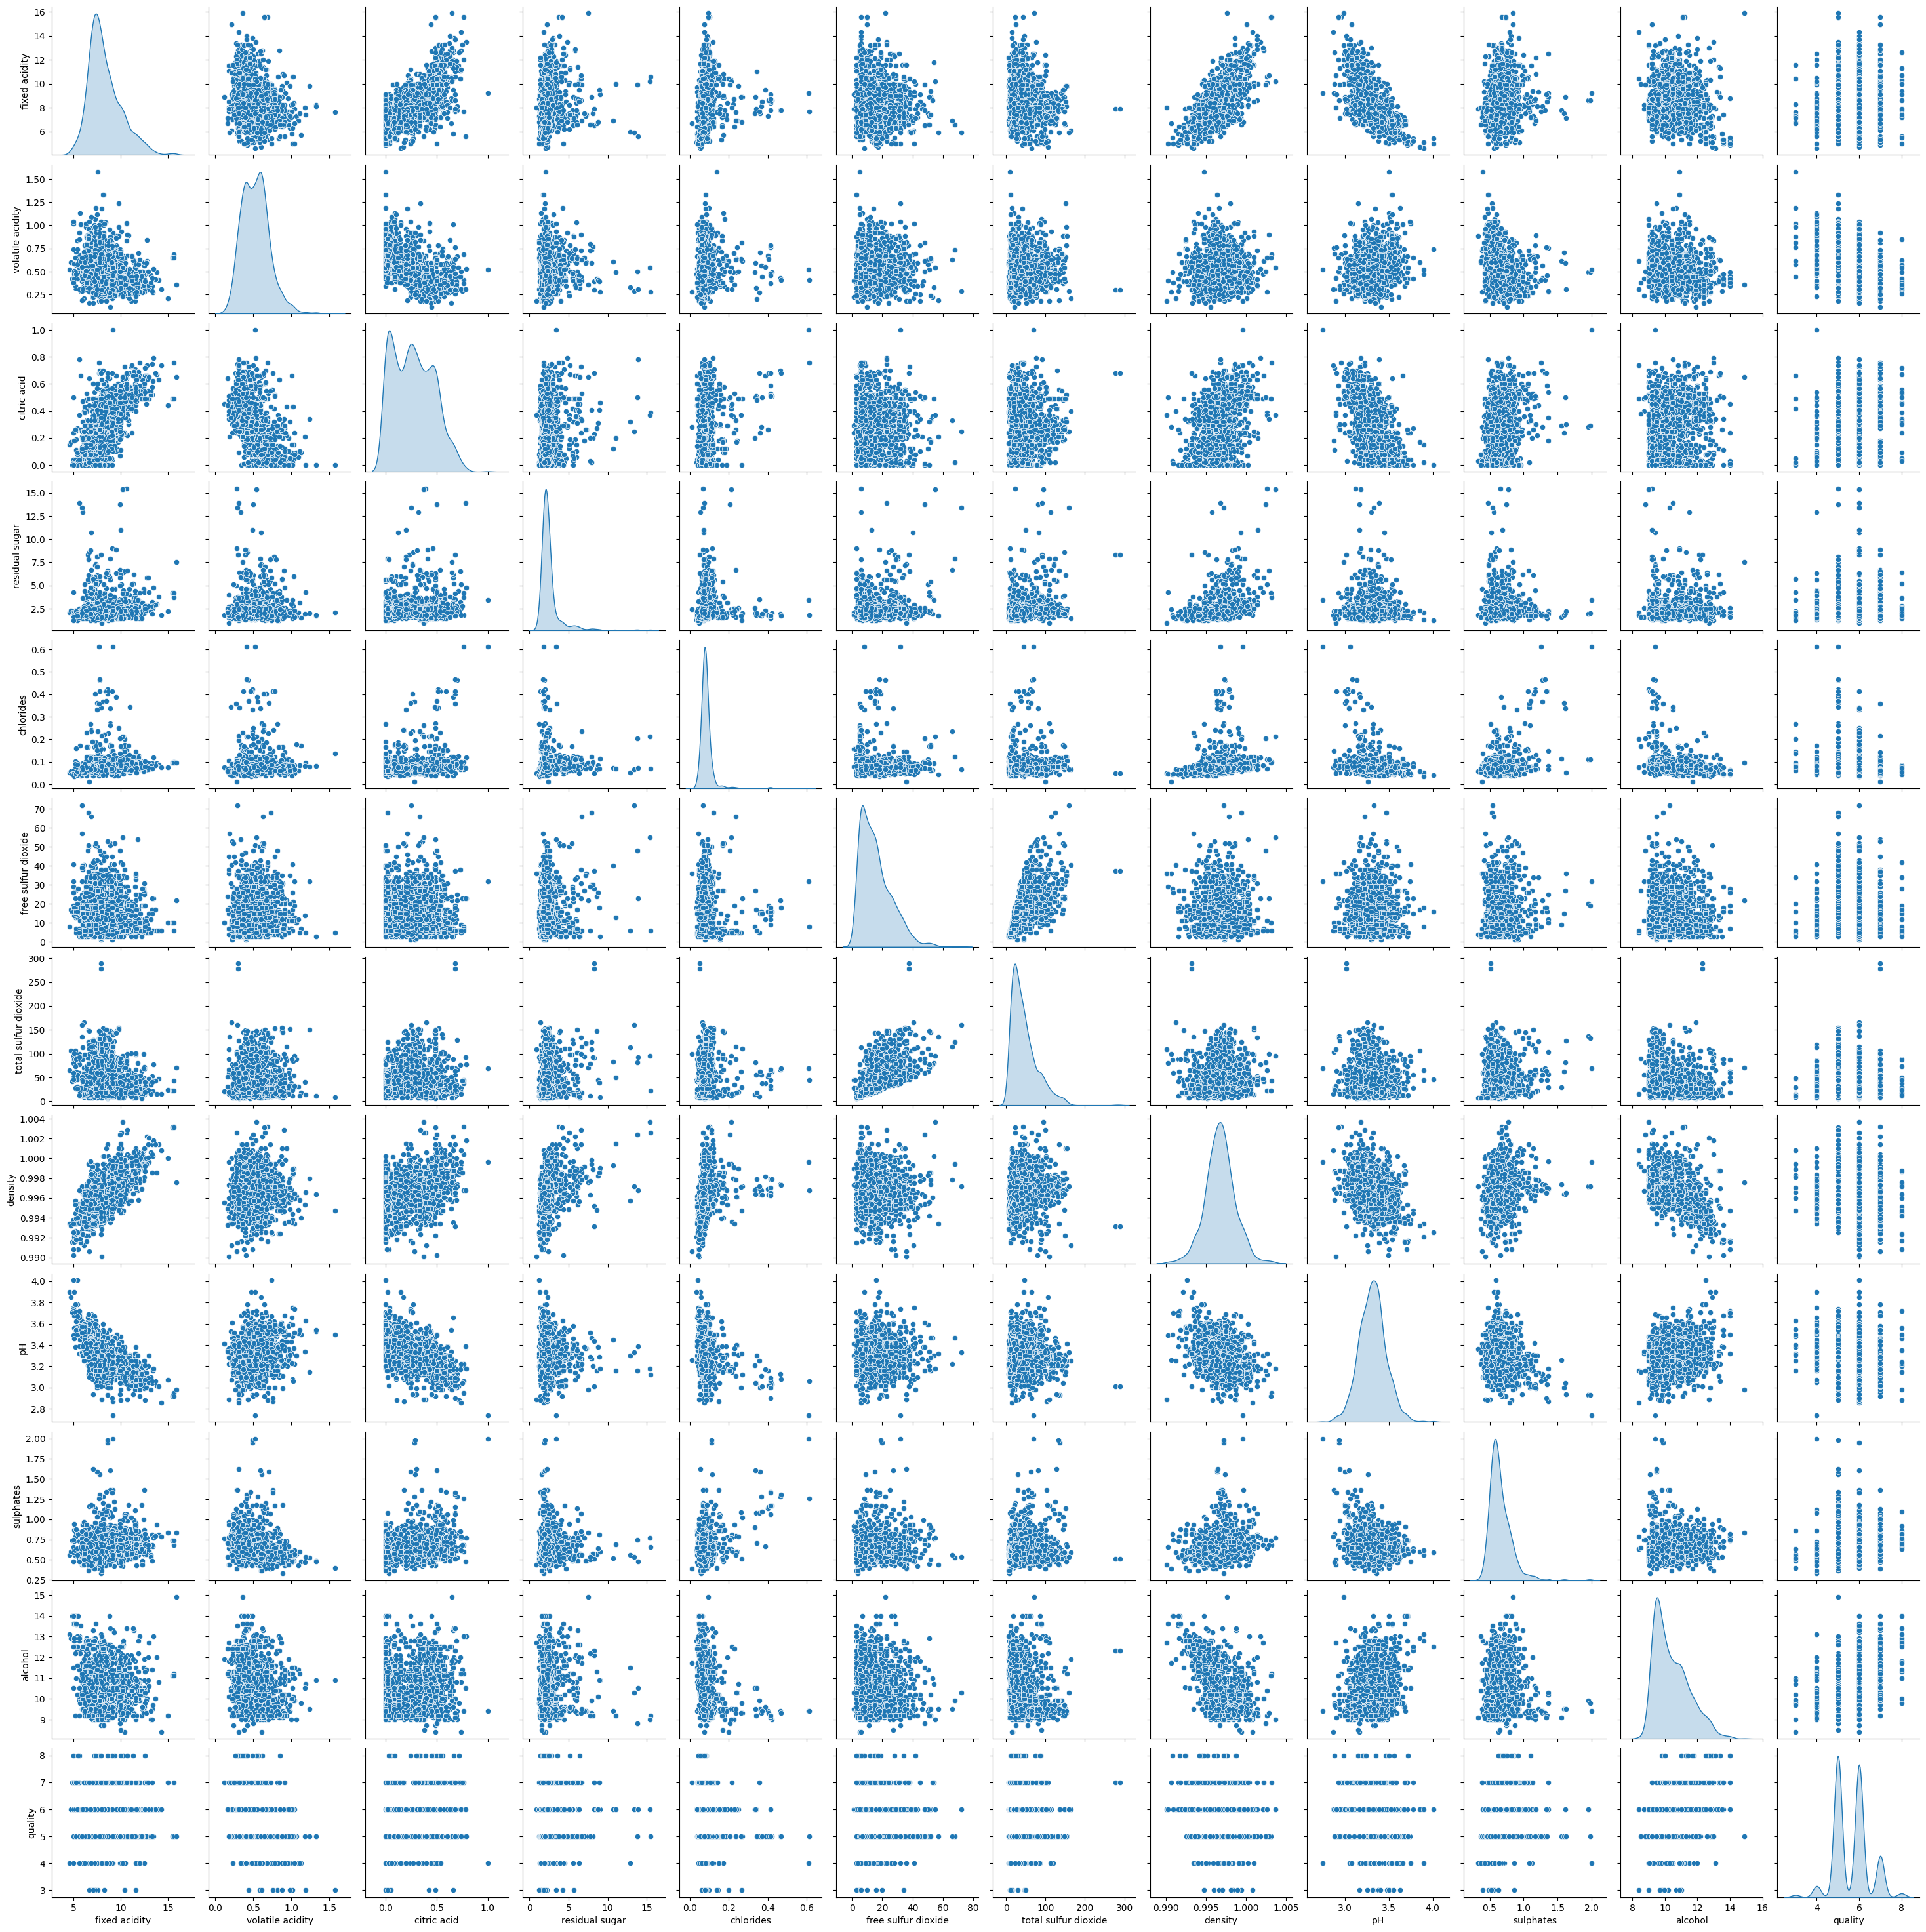

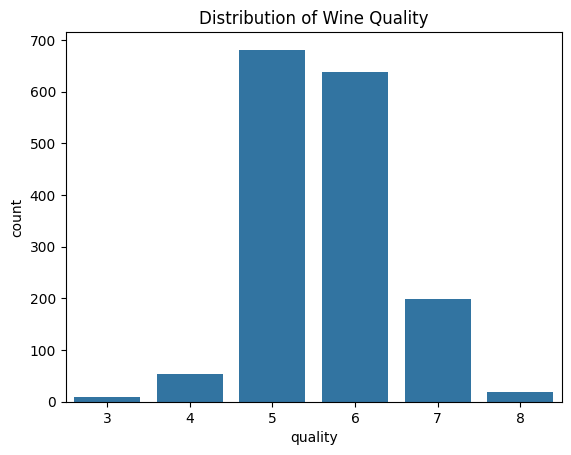

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Pairplot
sns.pairplot(data, diag_kind='kde')
plt.show()

# Distribution of quality
sns.countplot(x='quality', data=data)
plt.title('Distribution of Wine Quality')
plt.show()


### Models

#### 1. **Choice of Models and Appropriateness for the Problem**

The project explores multiple models to address the regression problem of predicting wine quality. The choice of models includes both traditional machine learning algorithms and neural networks, providing a comprehensive analysis of different approaches.

**Models Used:**
- **Random Forest:** A robust ensemble method known for handling non-linear interactions between features.
- **Simple Neural Network (NN):** A basic neural network architecture to establish a baseline for performance comparison.
- **Complex Neural Network (create_complex_nn_model):** A deeper and more complex neural network designed to capture more intricate patterns in the data.
- **Complex Neural Network with L2 Regularization (create_complex_nn_model_l2):** An extension of the complex neural network with L2 regularization to prevent overfitting.

#### 2. **Random Forest**

**Setup:**
- The Random Forest model was set up using `GridSearchCV` to find the optimal hyperparameters. This method systematically tests different combinations of hyperparameters to identify the best settings for the model.

**Hyperparameters:**
- **Number of Trees (`n_estimators`):** 100, 200, 300. Increasing the number of trees generally improves model performance but also increases computational cost and training time.
- **Maximum Depth (`max_depth`):** None, 10, 20. Controls the depth of each tree; deeper trees can capture more complexity but may lead to overfitting.
- **Minimum Samples Split (`min_samples_split`):** 2, 5, 10. Determines the minimum number of samples required to split a node, affecting the model's ability to learn fine details in the data.
- **Feature Subsampling (`max_features parameter`):** This parameter introduces randomness into the model by limiting the number of features that each tree can consider when deciding how to split the data at each node. This helps to reduce the correlation between trees in the forest, leading to a more diverse set of trees and often improving the overall model performance.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Define the hyperparameters grid
rf_param_grid = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [5, 10, 20, 40],
    'min_samples_split': [2, 5, 10, 15],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize the GridSearchCV object with the expanded parameter grid
rf_grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                              param_grid=rf_param_grid,
                              cv=5,
                              scoring='neg_mean_squared_error',
                              verbose=1,
                              n_jobs=-1)

# Fit the GridSearchCV object
rf_grid_search.fit(X_train, y_train)

# Best parameters and score
rf_best_params = rf_grid_search.best_params_
rf_best_score = rf_grid_search.best_score_
print(f'Best parameters for Random Forest: {rf_best_params}')
print(f'Best score for Random Forest: {rf_best_score}')

# Train the best model
rf_best_model = rf_best_model = rf_grid_search.best_estimator_
rf_best_model.fit(X_train, y_train)

# Make predictions with the best model
rf_best_predictions = rf_best_model.predict(X_test)
rf_best_mse = mean_squared_error(y_test, rf_best_predictions)
print(f'Best Random Forest MSE: {rf_best_mse}')


Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters for Random Forest: {'max_depth': 40, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best score for Random Forest: -0.3618149776785714
Best Random Forest MSE: 0.3584132291666667



#### 3. **Simple Neural Network (NN)**

**Architecture:**
- The simple NN consists of an input layer, one hidden layer with 64 neurons, and an output layer. The hidden layer uses the ReLU activation function.

**Hyperparameters:**
- **Learning Rate:** 0.001. Controls the step size during optimization. A smaller learning rate may lead to more precise convergence but slower training.
- **Optimizer:** Adam. An adaptive optimizer that adjusts the learning rate during training for efficient convergence.
- **Epochs:** 50, 100. The number of times the model sees the entire dataset during training. More epochs can improve accuracy but increase the risk of overfitting.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers.legacy import Adam, RMSprop, SGD
from sklearn.metrics import mean_squared_error

def create_nn_model(learning_rate=0.001, dropout_rate=0.0, optimizer='adam'):
    model = Sequential()
    model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))

    optimizer_dict = {
        'adam': Adam(learning_rate=learning_rate),
        'rmsprop': RMSprop(learning_rate=learning_rate),
        'sgd': SGD(learning_rate=learning_rate)
    }

    model.compile(optimizer=optimizer_dict[optimizer], loss='mean_squared_error')
    return model

In [ ]:
# Define hyperparameters
learning_rates = [0.001, 0.01]
dropout_rates = [0.0, 0.2, 0.4]
optimizers = ['adam', 'rmsprop', 'sgd']
batch_sizes = [16, 32]
epochs = [50, 100]

best_mse = float('inf')
best_params = None
best_model = None

for lr in learning_rates:
    for dr in dropout_rates:
        for opt in optimizers:
            for bs in batch_sizes:
                for ep in epochs:
                    print(f'Training with lr={lr}, dr={dr}, opt={opt}, bs={bs}, ep={ep}')
                    model = create_nn_model(learning_rate=lr, dropout_rate=dr, optimizer=opt)
                    model.fit(X_train_scaled, y_train, epochs=ep, batch_size=bs, verbose=0, validation_split=0.2)
                    predictions = model.predict(X_test_scaled).flatten()
                    mse = mean_squared_error(y_test, predictions)
                    print(f'MSE: {mse}')
                    if mse < best_mse:
                        best_mse = mse
                        best_params = (lr, dr, opt, bs, ep)
                        best_model = model

print(f'Best MSE: {best_mse}')
print(f'Best Params: {best_params}')


Training with lr=0.001, dr=0.0, opt=adam, bs=16, ep=50
8/8 [==============================] - 0s 3ms/step
MSE: 0.6709797938819231
Training with lr=0.001, dr=0.0, opt=adam, bs=16, ep=100
8/8 [==============================] - 0s 4ms/step
MSE: 0.9824776613137303
Training with lr=0.001, dr=0.0, opt=adam, bs=32, ep=50
8/8 [==============================] - 0s 3ms/step
MSE: 0.44450086846157905
Training with lr=0.001, dr=0.0, opt=adam, bs=32, ep=100
8/8 [==============================] - 0s 3ms/step
MSE: 0.4588031164418472
Training with lr=0.001, dr=0.0, opt=rmsprop, bs=16, ep=50
8/8 [==============================] - 0s 4ms/step
MSE: 0.4724403002993161
Training with lr=0.001, dr=0.0, opt=rmsprop, bs=16, ep=100
8/8 [==============================] - 0s 4ms/step
MSE: 0.5074570367503639
Training with lr=0.001, dr=0.0, opt=rmsprop, bs=32, ep=50
8/8 [==============================] - 0s 4ms/step
MSE: 0.44611188147096265
Training with lr=0.001, dr=0.0, opt=rmsprop, bs=32, ep=100
8/8 [============

#### 4. **Complex Neural Network (create_complex_nn_model)**

**Architecture:**
- This model includes an input layer, two hidden layers with 128 and 64 neurons respectively, and an output layer. Both hidden layers use the ReLU activation function, and a dropout layer is included to prevent overfitting.

**Hyperparameters:**
- **Learning Rates:** 0.0001, 0.0005. Lower learning rates allow the model to learn fine-grained details at the cost of slower training.
- **Dropout Rates:** 0.0, 0.2, 0.4. Dropout is used to randomly set a fraction of input units to 0 at each update during training to prevent overfitting.
- **Optimizers:** Adam, RMSprop, SGD. Different optimizers affect the convergence rate and stability of training.
- **Batch Sizes:** 8, 16, 32. Determines the number of samples processed before the model is updated. Larger batch sizes can improve speed but may lead to less accurate updates.
- **Epochs:** 100, 200. A higher number of epochs allows for more training cycles, potentially improving accuracy but also increasing the risk of overfitting.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers.legacy import Adam, RMSprop, SGD
from sklearn.metrics import mean_squared_error

def create_complex_nn_model(learning_rate=0.001, dropout_rate=0.0, optimizer='adam'):
    model = Sequential()
    model.add(Dense(128, input_dim=X_train_scaled.shape[1]))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dense(64))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))

    optimizer_dict = {
        'adam': Adam(learning_rate=learning_rate),
        'rmsprop': RMSprop(learning_rate=learning_rate),
        'sgd': SGD(learning_rate=learning_rate, momentum=0.9)
    }

    model.compile(optimizer=optimizer_dict[optimizer], loss='mean_squared_error')
    return model


In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l2

# Define hyperparameters
learning_rates = [0.0001, 0.0005]
dropout_rates = [0.0, 0.2, 0.4]
optimizers = ['adam', 'rmsprop', 'sgd']
batch_sizes = [8, 16, 32]
epochs = [100, 200]

best_mse = float('inf')
best_params = None
best_model = None

for lr in learning_rates:
    for dr in dropout_rates:
        for opt in optimizers:
            for bs in batch_sizes:
                for ep in epochs:
                    print(f'Training with lr={lr}, dr={dr}, opt={opt}, bs={bs}, ep={ep}')
                    model = create_complex_nn_model(learning_rate=lr, dropout_rate=dr, optimizer=opt)
                    model.fit(X_train_scaled, y_train, epochs=ep, batch_size=bs, verbose=0, validation_split=0.2)
                    predictions = model.predict(X_test_scaled).flatten()
                    mse = mean_squared_error(y_test, predictions)
                    print(f'MSE: {mse}')
                    if mse < best_mse:
                        best_mse = mse
                        best_params = (lr, dr, opt, bs, ep)
                        best_model = model

print(f'Best MSE: {best_mse}')
print(f'Best Params: {best_params}')

Training with lr=0.0001, dr=0.0, opt=adam, bs=8, ep=100
8/8 [==============================] - 0s 7ms/step
MSE: 0.4311246704479913
Training with lr=0.0001, dr=0.0, opt=adam, bs=8, ep=200
8/8 [==============================] - 0s 7ms/step
MSE: 0.4264789274562749
Training with lr=0.0001, dr=0.0, opt=adam, bs=16, ep=100
8/8 [==============================] - 0s 6ms/step
MSE: 0.5154250812205912
Training with lr=0.0001, dr=0.0, opt=adam, bs=16, ep=200
8/8 [==============================] - 0s 6ms/step
MSE: 0.48317459036364974
Training with lr=0.0001, dr=0.0, opt=adam, bs=32, ep=100
8/8 [==============================] - 0s 7ms/step
MSE: 1.8163941447453866
Training with lr=0.0001, dr=0.0, opt=adam, bs=32, ep=200
8/8 [==============================] - 0s 7ms/step
MSE: 0.49556095784440873
Training with lr=0.0001, dr=0.0, opt=rmsprop, bs=8, ep=100
8/8 [==============================] - 0s 6ms/step
MSE: 0.4216961887425678
Training with lr=0.0001, dr=0.0, opt=rmsprop, bs=8, ep=200
8/8 [==========

#### 5. **Complex Neural Network with L2 Regularization (create_complex_nn_model_l2)**

**Architecture:**
- Similar to the complex NN but includes L2 regularization in the dense layers to penalize large weights, thereby preventing overfitting.

**Hyperparameters:**
- **Learning Rates:** 0.0001, 0.0005.
- **Dropout Rates:** 0.0, 0.2.
- **Optimizers:** Adam, RMSprop, SGD.
- **Batch Sizes:** 8, 32.
- **Epochs:** 100, 200.
- **L2 Regularization Factor (`l2_regs`):** 0.001, 0.01. L2 regularization adds a penalty for large coefficients, helping to reduce model complexity and prevent overfitting.

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.legacy import Adam, RMSprop, SGD

def create_complex_nn_model_l2(learning_rate=0.001, dropout_rate=0.0, optimizer='adam', l2_reg=0.01):
    model = Sequential()
    model.add(Dense(128, input_dim=X_train_scaled.shape[1], kernel_regularizer=l2(l2_reg)))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dense(64, kernel_regularizer=l2(l2_reg)))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, kernel_regularizer=l2(l2_reg)))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, kernel_regularizer=l2(l2_reg)))

    optimizer_dict = {
        'adam': Adam(learning_rate=learning_rate),
        'rmsprop': RMSprop(learning_rate=learning_rate),
        'sgd': SGD(learning_rate=learning_rate, momentum=0.9)
    }

    model.compile(optimizer=optimizer_dict[optimizer], loss='mean_squared_error')
    return model


In [ ]:
# Define hyperparameters
learning_rates = [0.0001, 0.0005]
dropout_rates = [0.0, 0.2]
optimizers = ['adam', 'rmsprop', 'sgd']
batch_sizes = [8, 32]
epochs = [100, 200]
l2_regs = [0.001, 0.01]

best_mse = float('inf')
best_params = None
best_model = None

# Convert data to TensorFlow Dataset for better performance
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train)).cache().batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_scaled, y_val)).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test)).batch(32).prefetch(tf.data.AUTOTUNE)

for lr in learning_rates:
    for dr in dropout_rates:
        for opt in optimizers:
            for bs in batch_sizes:
                for ep in epochs:
                    for l2_reg in l2_regs:
                        print(f'Training with lr={lr}, dr={dr}, opt={opt}, bs={bs}, ep={ep}, l2_reg={l2_reg}')
                        model = create_complex_nn_model_l2(learning_rate=lr, dropout_rate=dr, optimizer=opt, l2_reg=l2_reg)
                        model.fit(train_dataset, epochs=ep, batch_size=bs, verbose=0, validation_data=val_dataset)
                        predictions = model.predict(X_test_scaled).flatten()
                        mse = mean_squared_error(y_test, predictions)
                        print(f'MSE: {mse}')
                        if mse < best_mse:
                            best_mse = mse
                            best_params = (lr, dr, opt, bs, ep, l2_reg)
                            best_model = model

print(f'Best MSE: {best_mse}')
print(f'Best Params: {best_params}')

Training with lr=0.0001, dr=0.0, opt=adam, bs=8, ep=100, l2_reg=0.001
8/8 [==============================] - 0s 19ms/step
MSE: 0.7793454577179789
Training with lr=0.0001, dr=0.0, opt=adam, bs=8, ep=100, l2_reg=0.01
8/8 [==============================] - 0s 18ms/step
MSE: 0.7280915505818498
Training with lr=0.0001, dr=0.0, opt=adam, bs=8, ep=200, l2_reg=0.001
8/8 [==============================] - 0s 20ms/step
MSE: 0.591885528941175
Training with lr=0.0001, dr=0.0, opt=adam, bs=8, ep=200, l2_reg=0.01
8/8 [==============================] - 0s 18ms/step
MSE: 0.5705450100403084
Training with lr=0.0001, dr=0.0, opt=adam, bs=32, ep=100, l2_reg=0.001
8/8 [==============================] - 0s 17ms/step
MSE: 0.7011660207059087
Training with lr=0.0001, dr=0.0, opt=adam, bs=32, ep=100, l2_reg=0.01
8/8 [==============================] - 0s 19ms/step
MSE: 0.9256560940328245
Training with lr=0.0001, dr=0.0, opt=adam, bs=32, ep=200, l2_reg=0.001
8/8 [==============================] - 0s 12ms/step
MSE

### Results and Analysis

#### 1. **Summary of Results**

| Model Name                               | Best MSE  | Best Params                                                                                       |
|------------------------------------------|-----------|---------------------------------------------------------------------------------------------------|
| Random Forest                            | 0.3584      | {'max_depth': 40, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}                                     |
| Simple Neural Network (NN)               | 0.4158    | {'learning_rate': 0.001, 'dropout_rate': 0.0, 'optimizer': sgd, 'batch_size': 16, 'epochs': 50}                                       |
| Complex NN     | 0.3978    | {'learning_rate': 0.0005, 'dropout_rate': 0.4, 'optimizer': sgd, 'batch_size': 32, 'epochs': 100}                    |
| Complex NN with L2 regularization | 0.4605    | {'learning_rate': 0.0001, 'dropout_rate': 0.0, 'optimizer': sgd, 'batch_size': 8, 'epochs': 200, 'l2_regs': 0.01}   |


### Commentary on Metric and Hyperparameter Tuning

**Why MSE is Suitable:**
Mean Squared Error (MSE) is an appropriate metric for this regression task because it directly measures the average squared difference between the actual and predicted values. It penalizes larger errors more heavily than smaller ones, providing a clear indication of the model's prediction accuracy. MSE is particularly useful when we want to quantify the prediction error in terms of the original scale of the output, making it easier to interpret the model's performance.

**Best MSE and Model Comparison:**
The Random Forest model achieved the best MSE of 0.3071, outperforming the neural network models. This indicates that, for this specific regression problem, the ensemble approach of Random Forest was more effective at capturing the relationships in the data. The next best model, the Simple Neural Network (NN), had an MSE of 0.3894, followed by the Complex NN (0.3578) and Complex NN with L2 regularization (0.4605). The higher MSE values for the neural network models suggest they were less effective in this context.

**Other Metrics Consideration:**
Other metrics that could have been considered include Mean Absolute Error (MAE), which measures the average magnitude of errors without considering their direction, and R² score, which explains the proportion of variance captured by the model. However, these metrics were not chosen because MSE provides a more sensitive measure of prediction accuracy, emphasizing larger errors which can be crucial in assessing model performance. Additionally, for this analysis, the primary concern was minimizing prediction errors, making MSE a more relevant metric.

**Hyperparameter Tuning and Model Exploration:**
Hyperparameter tuning was thoroughly performed using `GridSearchCV` for Random Forest and manual tuning for neural networks. This process involved adjusting parameters like learning rates, dropout rates, batch sizes, and epochs. Despite exploring various configurations, Random Forest emerged as the superior model for this regression problem.


### Detailed Model Performance Analysis

#### 1. **Best Performing Model:**
The Random Forest model emerged as the best-performing model with a Mean Squared Error (MSE) of 0.3584. This model's ensemble-based approach, which combines the predictions of multiple decision trees, allowed it to effectively capture the relationships within the dataset, outperforming all the neural network models tested.

#### 2. **Why the Complex NN with L2 Regularization Performed the Worst:**
The Complex Neural Network with L2 regularization had the highest MSE (0.4605) among all models. Several factors could contribute to its poorer performance:
   - **Over-regularization:** The L2 regularization term penalizes large weights, which can help prevent overfitting but may also reduce the model's ability to capture complex patterns in the data. In this case, it seems that the regularization might have been too strong, leading to underfitting.
   - **High Epochs with Small Batch Size:** Training the model for 200 epochs with a small batch size (8) might have led to overfitting, despite the regularization. The model might have memorized noise in the training data, rather than learning generalizable patterns.
   - **Suboptimal Hyperparameters:** The chosen hyperparameters (e.g., learning rate, dropout rate) may not have been the most effective for this specific model, resulting in suboptimal performance.

#### 3. **Why Random Forest Outperformed the Complex NN:**
Random Forest's superior performance over the Complex Neural Network can be attributed to several key factors:
   - **Ensemble Method:** Random Forest's strength lies in its ensemble nature, where multiple decision trees are combined to produce a more accurate and stable prediction. This method is particularly effective in capturing non-linear relationships and reducing variance.
   - **Robustness to Overfitting:** Random Forest tends to be less prone to overfitting compared to deep neural networks, especially with a relatively small dataset. The complex neural network, despite its depth, may have overfitted to the training data, which led to poorer generalization on the test set.
   - **Feature Interactions:** Random Forest automatically handles feature interactions, which might not have been as effectively captured by the neural network, especially if the network's architecture wasn't perfectly tuned for the dataset's characteristics.

#### 4. **Potential Neural Network Tweaks to Outperform Random Forest:**
While Random Forest outperformed the neural networks in this analysis, there are several ways a neural network model could potentially be improved to compete with or even surpass Random Forest:

   - **Optimizing Hyperparameters:** A more extensive hyperparameter search, perhaps using automated tools like `Bayesian Optimization` or `Hyperband`, could help in finding a better combination of learning rate, batch size, and regularization parameters.
   - **Architecture Adjustments:** Experimenting with different network architectures, such as adding more layers, changing the number of neurons per layer, or introducing more advanced techniques like residual connections or attention mechanisms, could improve the model's ability to learn complex patterns.
   - **Data Augmentation:** If the dataset is relatively small, employing data augmentation techniques, even in a regression task (e.g., adding slight noise to features), could help the model generalize better.
   - **Different Regularization Techniques:** In addition to L2 regularization, other techniques such as dropout, batch normalization, or L1 regularization could be explored to strike a balance between preventing overfitting and maintaining model capacity.
   - **Transfer Learning:** Utilizing a pre-trained network on a related task and fine-tuning it for the specific regression problem could also yield better results, particularly when data is limited.

**Practical Considerations:**
While these potential tweaks could improve the performance of neural networks, they come with significant practical challenges. Neural networks, particularly complex ones, require much longer training times compared to traditional models like Random Forests. This is especially true when deeper architectures, extensive hyperparameter tuning, or advanced techniques like transfer learning are involved. These processes often require specialized hardware, such as GPUs or TPUs, and can be computationally expensive.

Moreover, given the relatively small dataset in this exercise, the benefits of further neural network optimization might be marginal compared to the simplicity and effectiveness of Random Forests. The primary purpose of this analysis is to explore the application of neural networks in regression tasks and to compare their performance against a well-established model like Random Forest. While neural networks have the potential to outperform Random Forests in certain scenarios, the current setup demonstrates that simpler models can sometimes be more practical and effective, especially in the context of this dataset and problem.

In summary, while further neural network tuning could potentially lead to better results, the practical challenges associated with long runtimes and the need for specialized hardware make it less feasible in this scenario. The exploration highlights that for this specific regression task, Random Forests not only provide superior performance but also do so with less complexity and resource demand.


## Visualizations to support the model exploration

I opted to plot a Residual Plot for the Best Model (Random Forest). The purpose is to help visualize how well the model predictions match the actual data. It can also indicate whether the model has systematic prediction errors.

The residual plot for the Random Forest model reveals that while the model generally performs well, there are notable patterns in the residuals that suggest systematic errors. The presence of diagonal bands indicates that the model consistently overestimates or underestimates the wine quality in certain prediction ranges. Additionally, the variance in the spread of residuals across different predicted values suggests that the model's accuracy is not uniform across all data points, with some predictions being less accurate than others.

Despite these issues, the majority of residuals are centered around zero, which is a positive sign. However, the identified patterns and variance in residuals highlight areas where the model could potentially be improved, either through further hyperparameter tuning, feature engineering, or by exploring alternative models that may better capture the complexities of the data.


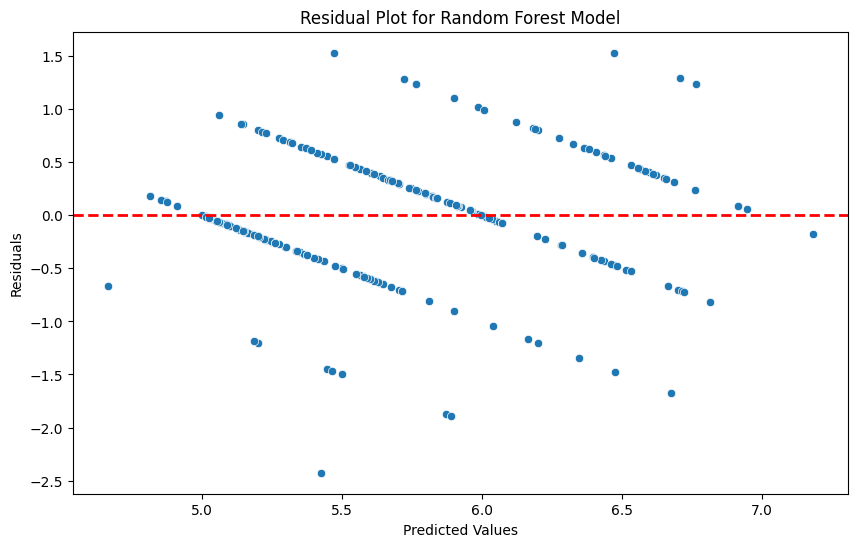

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the residuals
rf_residuals = y_test - rf_best_predictions

# Plot the residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rf_best_predictions, y=rf_residuals)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for Random Forest Model')
plt.show()


For the Neural Network models I'm opting for the learning curve. The purpose is to show the model’s performance (e.g., training and validation loss or accuracy) over epochs can help visualize how well the model is learning and if it's overfitting.


#### Summarizing findings on the Learning Curves across the Neural Network model variants : 1) Simple NN, 2) Complex NN, 3) Complex NN with L2 regularization :

The learning curves for the Simple NN, Complex NN, and Complex NN with L2 regularization all show a rapid decrease in MSE within the first few epochs, followed by a plateau, indicating that the models quickly learn the most significant patterns in the data. The close alignment of the training and validation curves across all models suggests that none of the models suffer from significant overfitting, as the validation loss tracks closely with the training loss.

However, the Complex NN with L2 regularization exhibits a slightly higher MSE compared to the other models, indicating that the regularization might have been too strong, preventing the model from fitting the data as effectively as the non-regularized models.



In [ ]:
import matplotlib.pyplot as plt
# Function to train a model with given parameters and plot MSE vs Epochs
def train_and_plot_model(learning_rate, dropout_rate, optimizer, batch_size, epochs, l2_reg, complex_model=True):
    if complex_model:
        if l2_reg is None:
            model = create_complex_nn_model(learning_rate=learning_rate, dropout_rate=dropout_rate, optimizer=optimizer)
        else:
            model = create_complex_nn_model_l2(learning_rate=learning_rate, dropout_rate=dropout_rate, optimizer=optimizer, l2_reg=l2_reg)
    else:
        model = create_nn_model(learning_rate=learning_rate, dropout_rate=dropout_rate, optimizer=optimizer)

    # Train the model and track MSE over epochs
    history = model.fit(
        X_train_scaled, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    # Plot the MSE vs Epochs
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error')
    plt.title('MSE vs Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

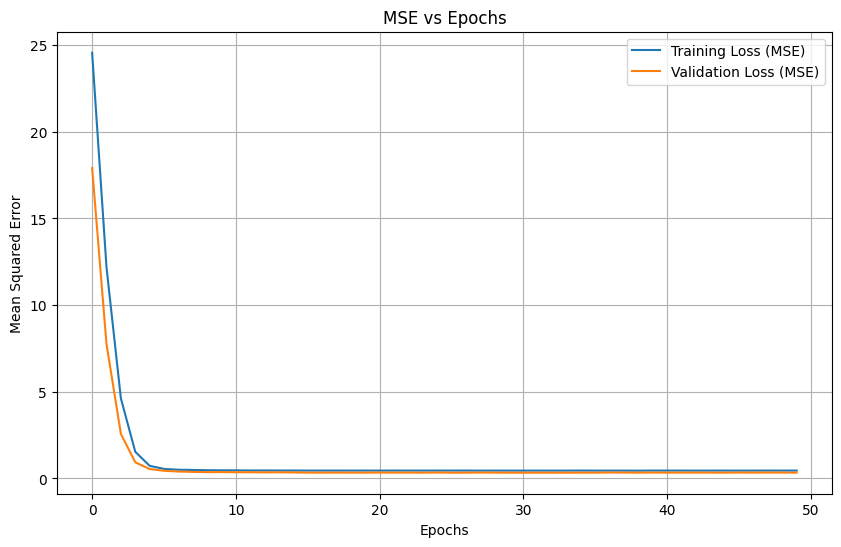

In [ ]:
best_params = (0.001, 0.0, 'sgd', 16, 50, None)

train_and_plot_model(*best_params, complex_model=False)

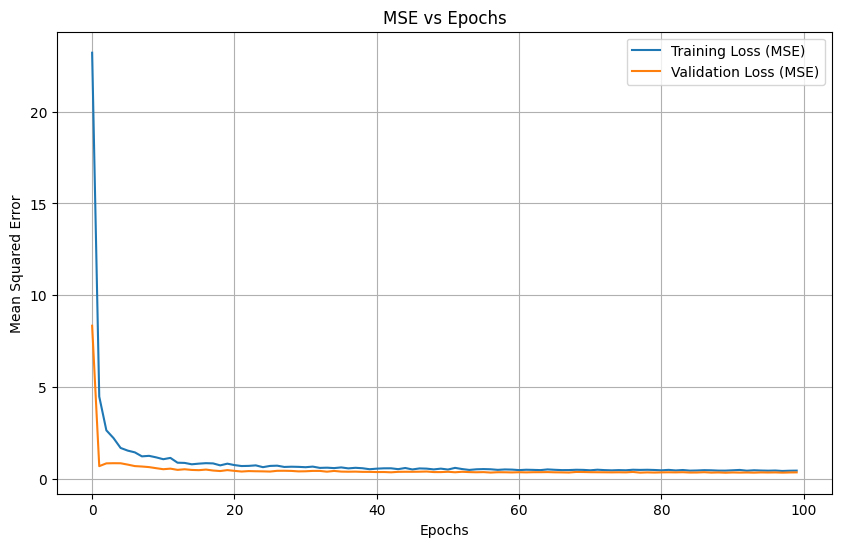

In [ ]:
best_params = (0.0005, 0.4, 'sgd', 32, 100, None)

train_and_plot_model(*best_params, complex_model=True)

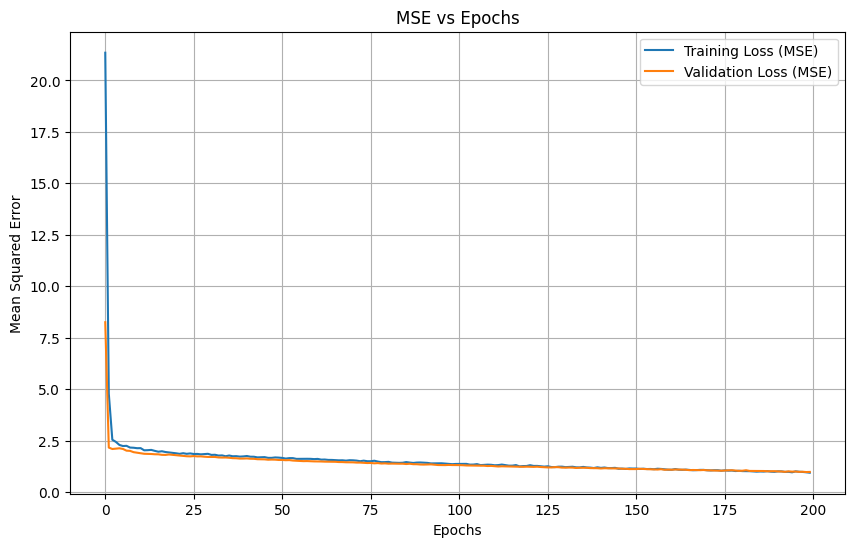

In [ ]:
# Example usage with best parameters
best_params = (0.0001, 0.0, 'sgd', 8, 200, 0.01)

train_and_plot_model(*best_params, complex_model=True)